# Student FULL name:Dipesh Subedi
# Student number:48803898



Acknowledgement Statement by students: <br>
Please keep one acknowledgment from the following<br>
	I acknowledge that I have only used GenAI (e. g., ChatGPT) in drafting and proofreading of this assignment, which is permitted in the assignment instructions.<br>



#  Answer to Section 1: 3 Interesting facts how students increase their performance

1. Students who spend more time studying are likely to achieve higher academic performance  
https://www.oecd.org/en/publications/pisa-2015-results-volume-ii_9789264267510-en.html
2. Teenagers who sleep 8 - 10 hours show better concentration, memory, and academic performance.
https://www.sleepfoundation.org/teens-and-sleep?
3. Poor sleep can negatively affect decision-making, cognitive function, and performance in students.
https://www.sleephealthfoundation.org.au/sleep-topics/memory-thinking-and-sleep

# Answer to Section 2: EDA 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Loading the dataset using na_values
df = pd.read_csv("Student_Performance.csv", na_values=['', ' ', 'NaN', 'nan', 'na', 'NA'])

In [6]:
# Displaying first five rows
df.head()

,Study Time,Prior Scores,Preferred Study Method,Academic Performance Score,Co-curricular Involvement,Hours of Sleep,Practice Papers Completed,Preferred Study Location,Age
0,7,99.93,Solo,91.70,Yes,9.0,1,CafÈ,21.0
1,4,82.99,Solo,65.25,No,4.0,2,CafÈ,21.0
2,8,51.74,Tutor,45.22,Yes,7.0,2,Home,22.0
3,5,52.35,Tutor,36.74,Yes,5.0,2,CafÈ,21.0
4,7,75.16,Solo,66.48,No,8.0,5,Library,20.0


In [7]:
# Checking number of rows and columns
df.shape

(10001, 9)

In [8]:
# Displaying dataset structure and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Study Time                  10001 non-null  int64  
 1   Prior Scores                10000 non-null  float64
 2   Preferred Study Method      10001 non-null  object 
 3   Academic Performance Score  10000 non-null  float64
 4   Co-curricular Involvement   10000 non-null  object 
 5   Hours of Sleep              10000 non-null  float64
 6   Practice Papers Completed   10001 non-null  int64  
 7   Preferred Study Location    10000 non-null  object 
 8   Age                         10000 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 703.3+ KB


In [9]:
#Checking missing values
df.isnull().sum()

Study Time                    0
Prior Scores                  1
Preferred Study Method        0
Academic Performance Score    1
Co-curricular Involvement     1
Hours of Sleep                1
Practice Papers Completed     0
Preferred Study Location      1
Age                           1
dtype: int64

In [10]:
# Filling missing values in numerical columns with median
for col in ['Prior Scores', 'Academic Performance Score', 'Hours of Sleep', 'Age']:
    df[col] = df[col].fillna(df[col].median())

# Filling missing values in categorical columns with mode
for col in ['Co-curricular Involvement', 'Preferred Study Location']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Confirming no missing values remain
df.isnull().sum()

Study Time                    0
Prior Scores                  0
Preferred Study Method        0
Academic Performance Score    0
Co-curricular Involvement     0
Hours of Sleep                0
Practice Papers Completed     0
Preferred Study Location      0
Age                           0
dtype: int64

In [11]:
#Generate descriptive statistics
df.describe()

,Study Time,Prior Scores,Academic Performance Score,Hours of Sleep,Practice Papers Completed,Age
count,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000
mean,4.992501,69.941555,55.723754,6.530647,4.583742,21.011299
std,2.589487,17.346695,19.203972,1.695785,2.867545,1.407612
min,1.000000,40.010000,10.630000,4.000000,0.000000,19.000000
25%,3.000000,54.930000,40.660000,5.000000,2.000000,20.000000
50%,5.000000,69.730000,55.720000,7.000000,5.000000,21.000000
75%,7.000000,85.200000,71.030000,8.000000,7.000000,22.000000
max,9.000000,99.980000,100.750000,9.000000,9.000000,23.000000


In [12]:
# Checking for duplicate rows
print(df.duplicated().sum())

# Dropping the duplicate rows
df = df.drop_duplicates()

1


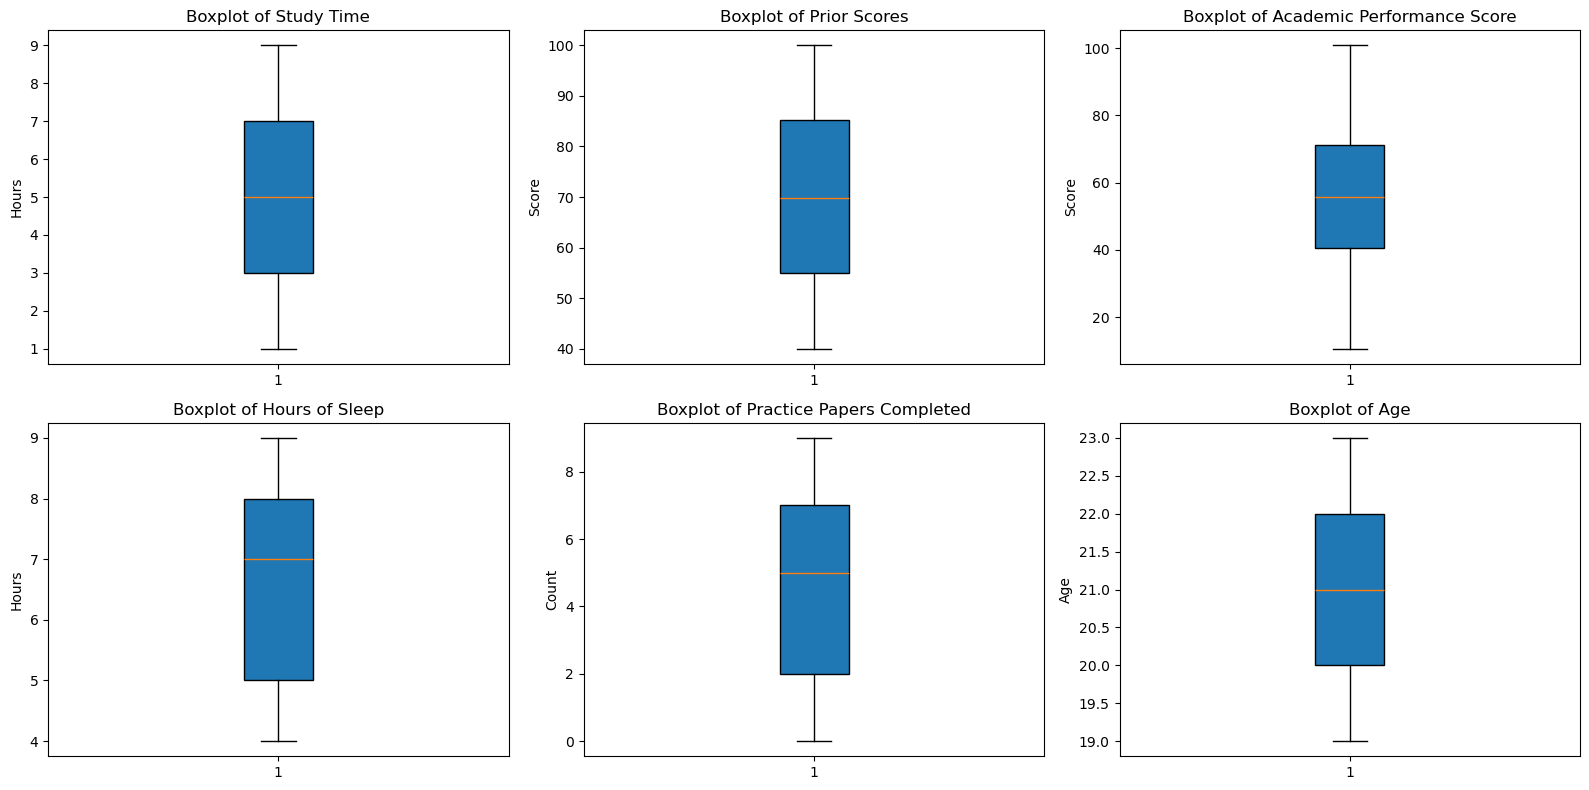

In [13]:
# Boxplots to check for outliers across all numerical columns
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.boxplot(df['Study Time'], patch_artist=True)
plt.title('Boxplot of Study Time')
plt.ylabel('Hours')

plt.subplot(2, 3, 2)
plt.boxplot(df['Prior Scores'], patch_artist=True)
plt.title('Boxplot of Prior Scores')
plt.ylabel('Score')

plt.subplot(2, 3, 3)
plt.boxplot(df['Academic Performance Score'], patch_artist=True)
plt.title('Boxplot of Academic Performance Score')
plt.ylabel('Score')

plt.subplot(2, 3, 4)
plt.boxplot(df['Hours of Sleep'], patch_artist=True)
plt.title('Boxplot of Hours of Sleep')
plt.ylabel('Hours')

plt.subplot(2, 3, 5)
plt.boxplot(df['Practice Papers Completed'], patch_artist=True)
plt.title('Boxplot of Practice Papers Completed')
plt.ylabel('Count')

plt.subplot(2, 3, 6)
plt.boxplot(df['Age'], patch_artist=True)
plt.title('Boxplot of Age')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

In [14]:
# Measuring skewness in all numerical columns
df.skew(numeric_only=True)

Study Time                   -0.004213
Prior Scores                  0.004899
Academic Performance Score   -0.001976
Hours of Sleep               -0.039474
Practice Papers Completed    -0.035636
Age                          -0.004581
dtype: float64

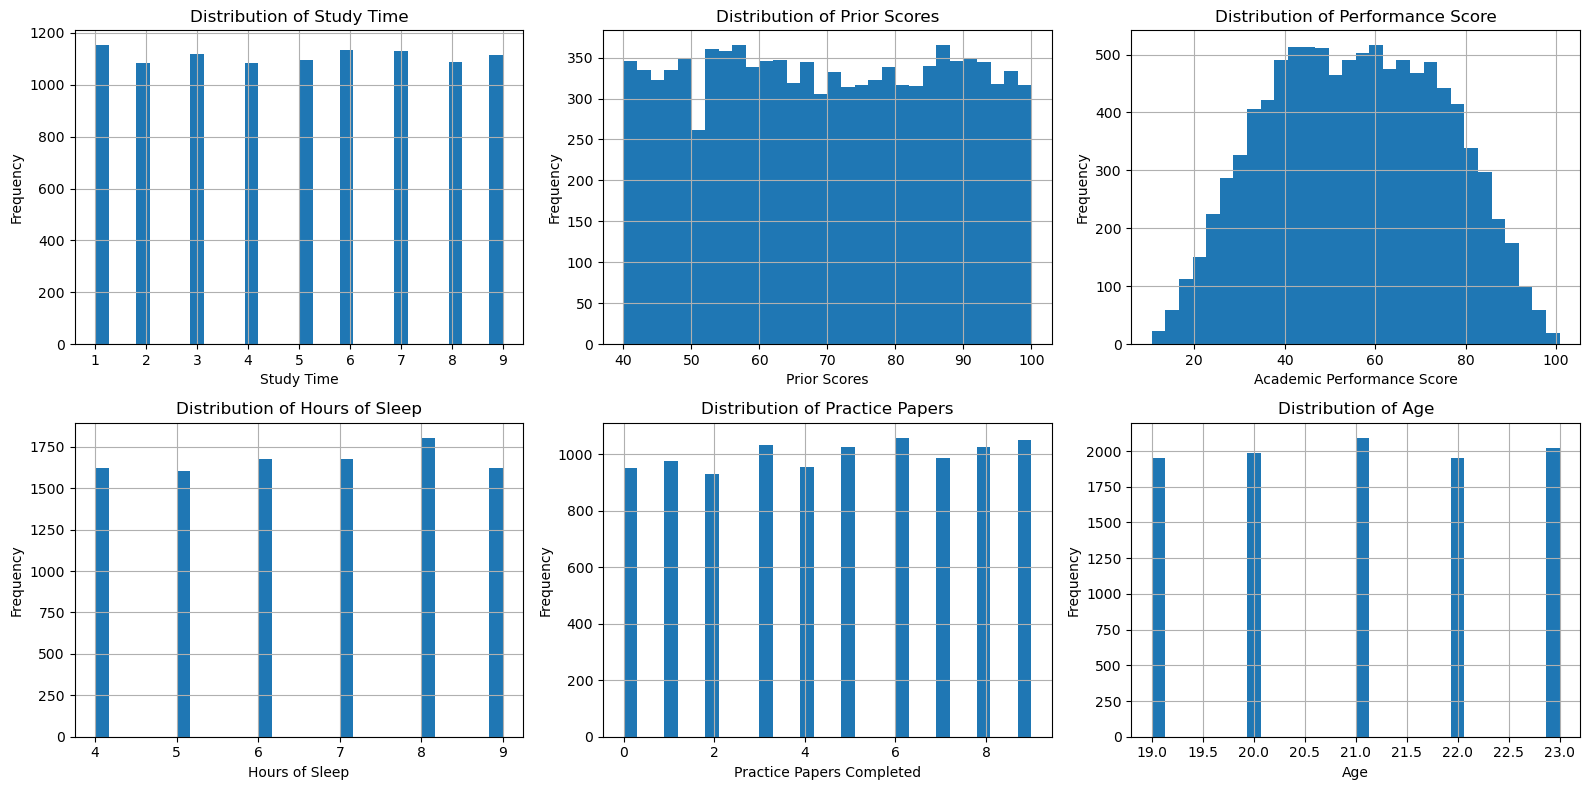

In [15]:
# Visualising distribution of all numerical columns
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
df['Study Time'].hist(bins=30)
plt.title('Distribution of Study Time')
plt.xlabel('Study Time')
plt.ylabel('Frequency')

plt.subplot(2, 3, 2)
df['Prior Scores'].hist(bins=30)
plt.title('Distribution of Prior Scores')
plt.xlabel('Prior Scores')
plt.ylabel('Frequency')

plt.subplot(2, 3, 3)
df['Academic Performance Score'].hist(bins=30)
plt.title('Distribution of Performance Score')
plt.xlabel('Academic Performance Score')
plt.ylabel('Frequency')

plt.subplot(2, 3, 4)
df['Hours of Sleep'].hist(bins=30)
plt.title('Distribution of Hours of Sleep')
plt.xlabel('Hours of Sleep')
plt.ylabel('Frequency')

plt.subplot(2, 3, 5)
df['Practice Papers Completed'].hist(bins=30)
plt.title('Distribution of Practice Papers')
plt.xlabel('Practice Papers Completed')
plt.ylabel('Frequency')

plt.subplot(2, 3, 6)
df['Age'].hist(bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Answer to Section 3 Multiple Linear Regression Analysis

The purpose of this section is to identify the factors that significantly influence academic performance score using multiple regression analysis



In [16]:
import statsmodels.api as sm

In [17]:
# Identify categorical columns
categorical_cols = ['Preferred Study Location',
                    'Co-curricular Involvement',
                    'Preferred Study Method']

# Perform one-hot encoding
df_encoded = pd.get_dummies(df,
                            columns=categorical_cols,
                            drop_first=True,
                           dtype=int)

# Display first five rows
df_encoded.head()

,Study Time,Prior Scores,Academic Performance Score,Hours of Sleep,Practice Papers Completed,Age,Preferred Study Location_Home,Preferred Study Location_Library,Preferred Study Location_School,Co-curricular Involvement_Yes,Preferred Study Method_Solo,Preferred Study Method_Tutor
0,7,99.93,91.70,9.0,1,21.0,0,0,0,1,1,0
1,4,82.99,65.25,4.0,2,21.0,0,0,0,0,1,0
2,8,51.74,45.22,7.0,2,22.0,1,0,0,1,0,1
3,5,52.35,36.74,5.0,2,21.0,0,0,0,1,0,1
4,7,75.16,66.48,8.0,5,20.0,0,1,0,0,1,0


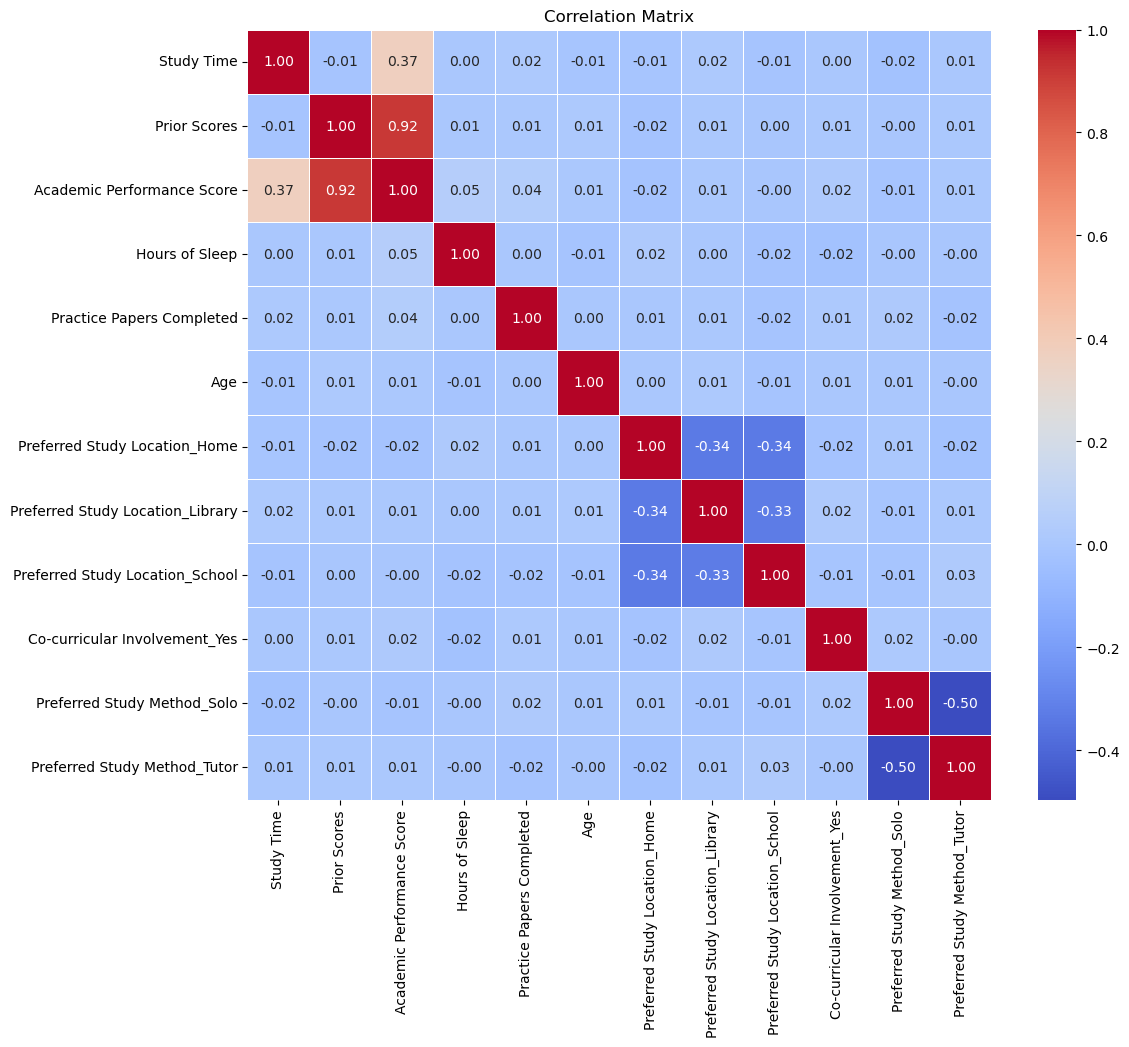

In [18]:
# Compute the correlation matrix
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Correlation Matrix')

plt.show()

The correlation heatmap shows prior scores have strong positive relationship with academic performance score. Study time also shows moderate positive relationship with performance. Other shows weak correlations.

In [19]:
# Define independent variables
X = df_encoded.drop('Academic Performance Score', axis=1)

# Define dependent variable
y = df_encoded['Academic Performance Score']

In [20]:
# Add constant term to regression model
X = sm.add_constant(X)

In [21]:
# Build regression model
model = sm.OLS(y, X).fit()

# Display regression summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Academic Performance Score   R-squared:                       0.988
Model:                                    OLS   Adj. R-squared:                  0.988
Method:                         Least Squares   F-statistic:                 7.645e+04
Date:                        Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                                12:42:40   Log-Likelihood:                -21516.
No. Observations:                       10000   AIC:                         4.306e+04
Df Residuals:                            9988   BIC:                         4.314e+04
Df Model:                                  11                                         
Covariance Type:                    nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                              -34.2522      0.340   -100.620      0.000     -34.919     -33.585
Study Time                           2.8507      0.008    354.286      0.000       2.835       2.866
Prior Scores                         1.0177      0.001    847.629      0.000       1.015       1.020
Hours of Sleep                       0.4827      0.012     39.290      0.000       0.459       0.507
Practice Papers Completed            0.1918      0.007     26.405      0.000       0.178       0.206
Age                                  0.0075      0.015      0.504      0.614      -0.022       0.036
Preferred Study Location_Home        0.0919      0.059      1.570      0.117      -0.023       0.207
Preferred Study Location_Library     0.0125      0.059      0.212      0.832      -0.103       0.128
Preferred Study Location_School      0.1723      0.059      2.911      0.004       0.056       0.288
Co-curricular Involvement_Yes        0.6208      0.042     14.897      0.000       0.539       0.702
Preferred Study Method_Solo          0.0124      0.051      0.244      0.807      -0.087       0.112
Preferred Study Method_Tutor        -0.0211      0.051     -0.413      0.680      -0.121       0.079
==============================================================================
Omnibus:                       13.951   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               16.442
Skew:                           0.000   Prob(JB):                     0.000269
Kurtosis:                       3.199   Cond. No.                     1.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

R-square is 0.988 so there is 98.8% of the variation in academic performance and the f-statisitic is p = 0.00. So, the model is a good fit

## Assumption 1: Linearity 

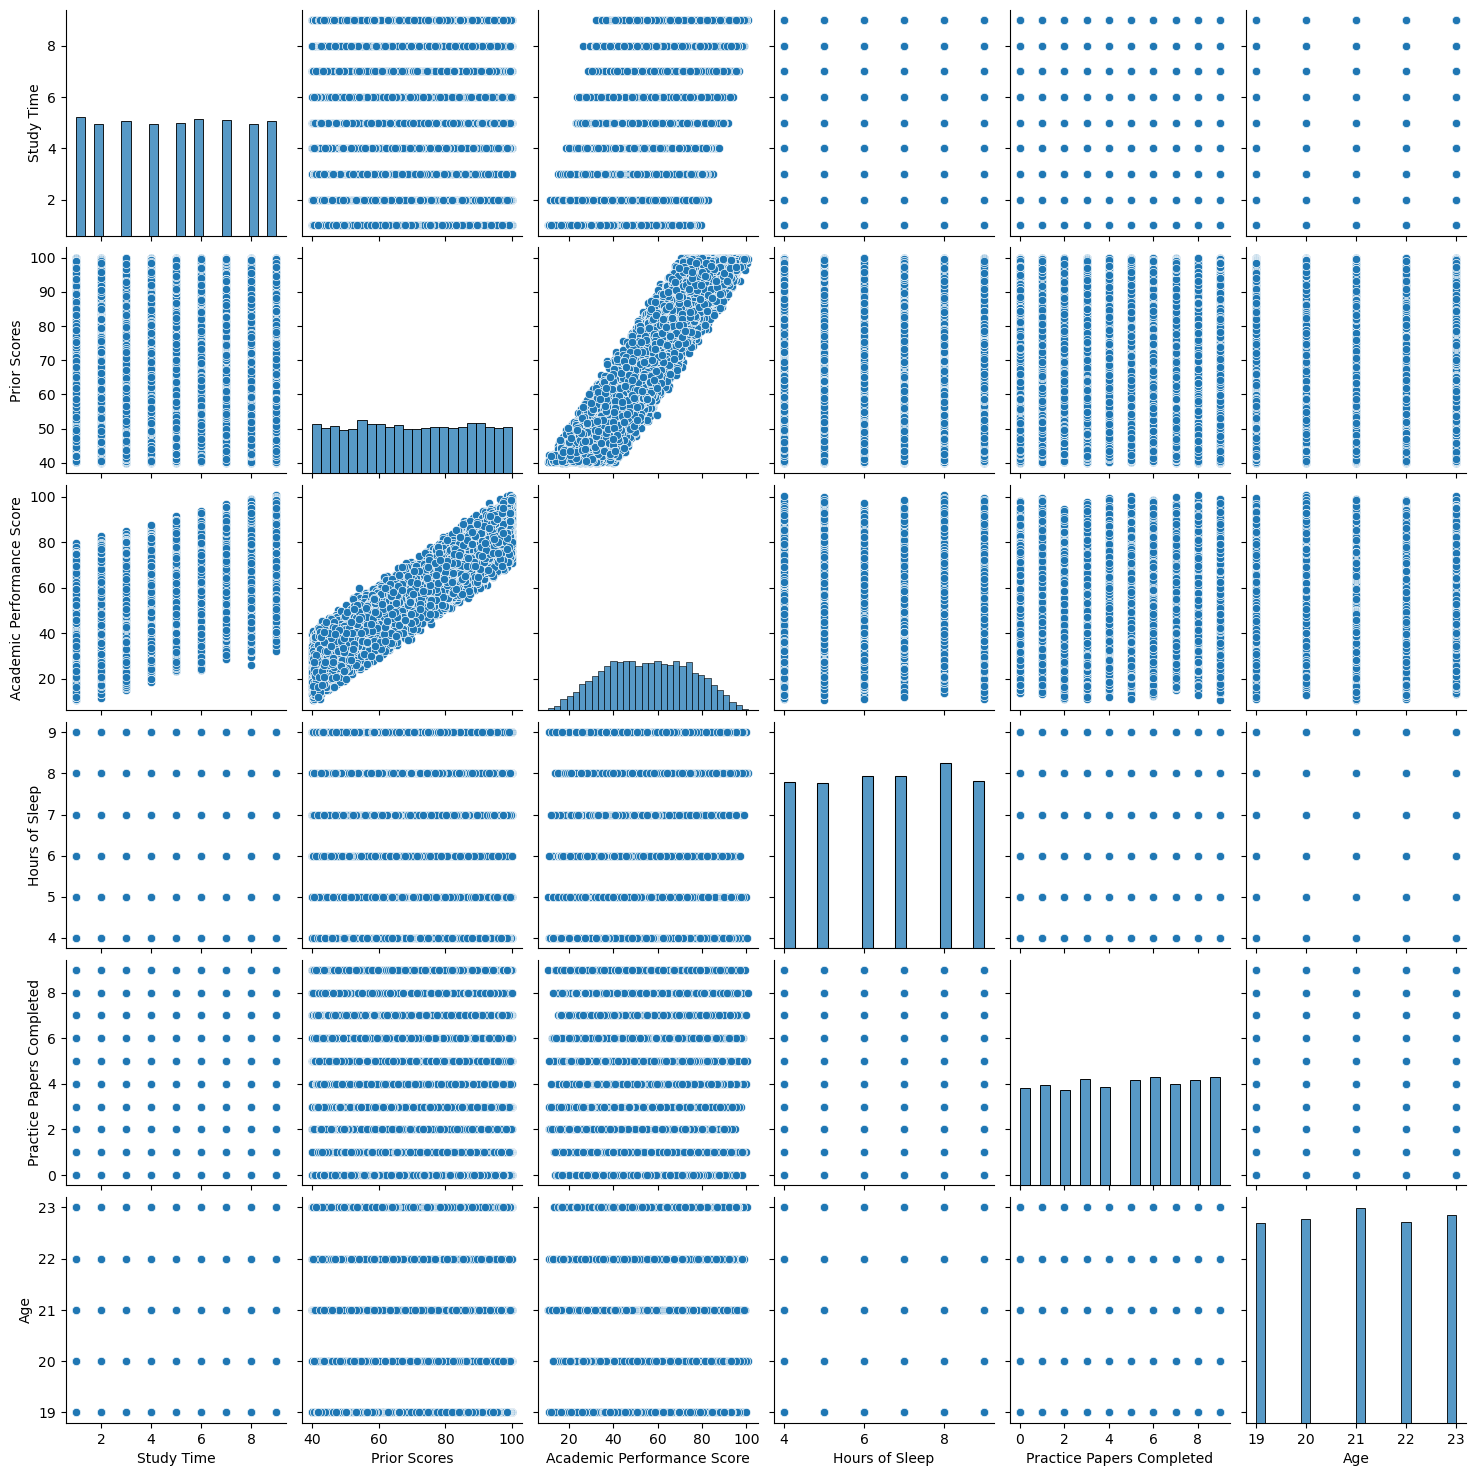

In [22]:
sns.pairplot(df)
plt.show()

This pairplot shows linear relationship between several predictors and academic performance score. The linear assumption appears reasonably satisfied

## Assumption 2: Multicollinearity

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF values
vif_data = pd.DataFrame()

vif_data['Feature'] = X.columns

vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

# Display VIF table
print(vif_data)

                             Feature         VIF
0                              const  267.390623
1                         Study Time    1.001514
2                       Prior Scores    1.000931
3                     Hours of Sleep    1.001354
4          Practice Papers Completed    1.001348
5                                Age    1.000830
6      Preferred Study Location_Home    1.507754
7   Preferred Study Location_Library    1.499180
8    Preferred Study Location_School    1.497396
9      Co-curricular Involvement_Yes    1.001725
10       Preferred Study Method_Solo    1.327241
11      Preferred Study Method_Tutor    1.327228


The vif values of all predictor is less than 5. So there is no multicollinearity problem in the regression model.

## Assumption 3 — Homoscedasticity

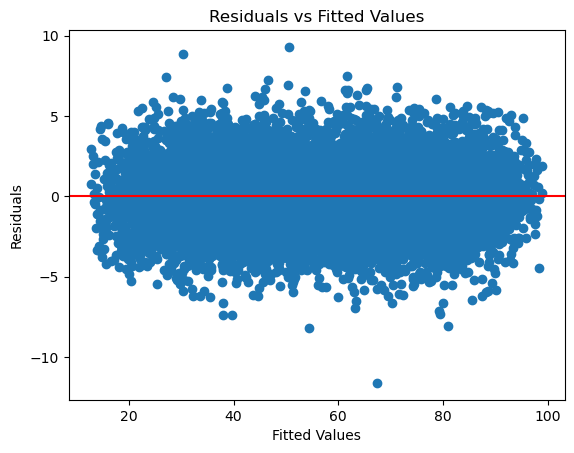

In [24]:
# Residuals vs fitted values plot
plt.scatter(model.fittedvalues,
            model.resid)

plt.axhline(y=0,
            color='red')

plt.xlabel('Fitted Values')

plt.ylabel('Residuals')

plt.title('Residuals vs Fitted Values')

plt.show()

The residuals shows randomly scattered around zero with no clear pattern. So, the homoscedasticity is satisfied

## Assumption 4: Normality of Residuals

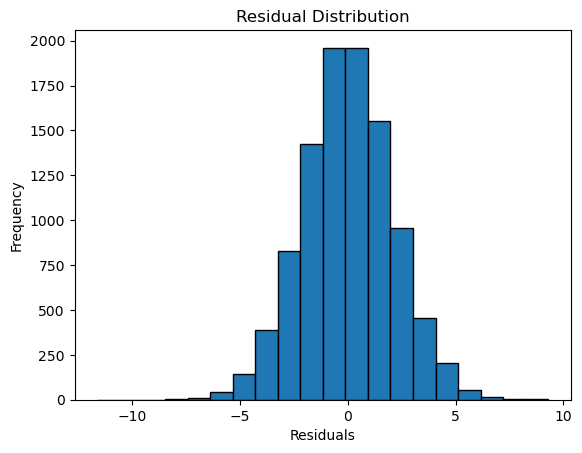

In [25]:
residuals = model.resid

plt.hist(
    residuals,
    bins=20,
    edgecolor='black'
)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.ylabel("Frequency")

plt.show()

The histogram shows a bell-shaped distribution centred around zero

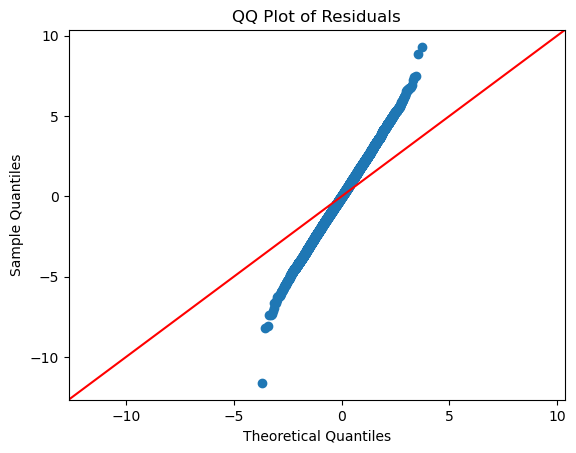

In [26]:
sm.qqplot(residuals, line='45')

plt.title("QQ Plot of Residuals")

plt.show()

The qq plot shows the residuals follows the redline only in the middle region. At the upper tail points go above the line and at the lower tail few points drop very low. This shows the residuals is not perfectly normal. We have larger set n = 10000 so this does not affect model result. 

## Assumption 5: Independence of Errors

In [44]:
from statsmodels.stats.stattools import durbin_watson

# Durbin-Watson test
durbin_watson(model.resid)


np.float64(1.9968433087397017)

The durbin-watson test is 1.9968 which is close to 2 which shows no autocorrelation. The errors are independent.